Build a very simple Binary Classifire NN

#### work process example

In [76]:
from nn import MLP

In [77]:
# four possible inputs 
xs = [
    [2.0, 3.0, -2.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

In [78]:
model = MLP(3, [4, 4, 1])

In [104]:
for i in range(10):
    ypred = [model(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    model.zero_grad()
    loss.backward()
    
    for p in model.parameters():
        p.data -= 0.1 * p.grad

    print(f"{i} | {loss.data}")

0 | 0.0008311715135759908
1 | 0.000827681108921122
2 | 0.0008242192178224161
3 | 0.0008207854956866045
4 | 0.0008173796034205799
5 | 0.000814001207322498
6 | 0.0008106499789754053
7 | 0.0008073255951434309
8 | 0.0008040277376703384
9 | 0.0008007560933805083


In [105]:
ypred

[Value(data=0.9891938160159526, grad=-0.021612367968094848),
 Value(data=-0.992503709760604, grad=0.01499258047879204),
 Value(data=-0.9835171373050174, grad=0.03296572538996512),
 Value(data=0.9811292991357365, grad=-0.03774140172852691)]

In [107]:
model([2.5, -1.0, -0.5])

Value(data=-0.9902861796735997, grad=0.0)

#### more complex thing

In [108]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [109]:
from nn import MLP
# from engine import Value

In [110]:
# np.random.seed(52)
# random.seed(52)

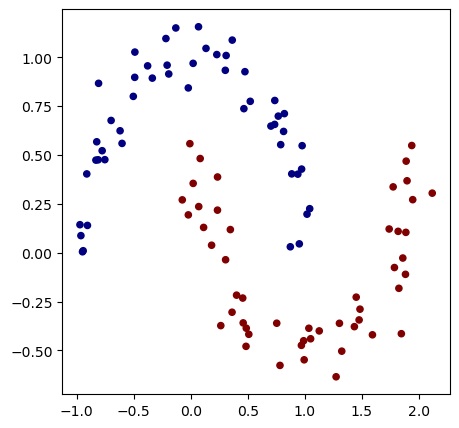

In [111]:
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1  # tanh() works better if y in (-1, 1) then in (0, 1)
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [127]:
# initialize model with 2 input parameters (X coordinates)
model = MLP(2, [16, 16, 1]) 
print("number of parameters:", len(model.parameters()))

number of parameters: 337


In [113]:
def loss():
    scores = list(map(model, X))

    total_loss = sum((yout - ygt)**2 for ygt, yout in zip(y, scores))

    accuracy = [(ygt > 0) == (yout.data > 0) for ygt, yout in zip(y, scores)]

    return total_loss, sum(accuracy) / len(accuracy)
    

In [120]:
total_loss, acc = loss()
print(total_loss, acc)

Value(data=250.40712774150813, grad=0.0) 0.28


In [128]:
# learning
for i in range(100):

    # forward
    total_loss, acc = loss()

    # backward
    model.zero_grad()
    total_loss.backward()

    learning_rate = 0.005
    for p in model.parameters():
        p.data -= learning_rate * p.grad

    if i % 2 == 0:
        print(f"step {i} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 286.6768728439065, accuracy 24.0%
step 2 loss 81.60029170259139, accuracy 79.0%
step 4 loss 74.49994682942425, accuracy 81.0%
step 6 loss 73.13926907566758, accuracy 81.0%
step 8 loss 71.52039155855113, accuracy 82.0%
step 10 loss 69.00867369778902, accuracy 81.0%
step 12 loss 65.12470801178388, accuracy 83.0%
step 14 loss 50.42781854403262, accuracy 86.0%
step 16 loss 40.65606222547126, accuracy 88.0%
step 18 loss 32.596425315079145, accuracy 89.0%
step 20 loss 30.216498708503032, accuracy 91.0%
step 22 loss 28.833732592886605, accuracy 91.0%
step 24 loss 26.244305542134782, accuracy 91.0%
step 26 loss 23.656583567932923, accuracy 92.0%
step 28 loss 20.995846618651417, accuracy 95.0%
step 30 loss 18.717550465772288, accuracy 96.0%
step 32 loss 17.60359648710839, accuracy 96.0%
step 34 loss 17.080856720487706, accuracy 96.0%
step 36 loss 14.921809370859977, accuracy 96.0%
step 38 loss 13.771187263384961, accuracy 96.0%
step 40 loss 14.62721471778354, accuracy 96.0%
step 42 

(-1.634807108127236, 2.115192891872764)

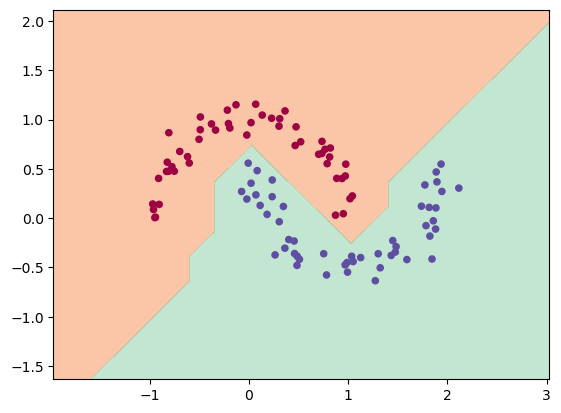

In [158]:
grid_step = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, grid_step), 
                     np.arange(y_min, y_max, grid_step))

Xmesh = np.c_[xx.ravel(), yy.ravel()]

scores = list(map(model, Xmesh)) # get a prediction for every dot of the grid
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)
fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

In [153]:
xx.shape

(16, 21)

In [134]:
xx

array([[-1.97099682, -0.97099682,  0.02900318,  1.02900318,  2.02900318,
         3.02900318],
       [-1.97099682, -0.97099682,  0.02900318,  1.02900318,  2.02900318,
         3.02900318],
       [-1.97099682, -0.97099682,  0.02900318,  1.02900318,  2.02900318,
         3.02900318],
       [-1.97099682, -0.97099682,  0.02900318,  1.02900318,  2.02900318,
         3.02900318]])